In [2]:
from torch.utils.data import DataLoader
from src.dataloader import TrashCanDataset
import torch
from src.model import ObjDetector,save_detector,load_detector,ObjDetectorRPN
# from src.model2 import ObjDetectorRPN
import os
import gc

c:\Users\chris\.conda\envs\deep_learning_cuda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Building vocabulary (images):  95%|█████████▍| 289/305 [01:08<00:03,  4.22it/s]


Collected 5000 positive patches for BoVW vocabulary.


Epoch [5/100]: 100%|██████████| 387/387 [00:26<00:00, 14.34batch/s, Training loss=2.06, Validation Loss=2.11]


Showing validation sample predictions...


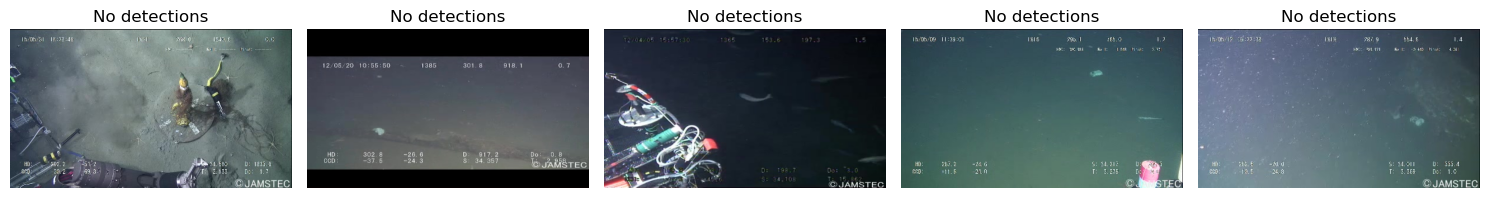

Epoch [10/100]: 100%|██████████| 387/387 [00:26<00:00, 14.82batch/s, Training loss=1.95, Validation Loss=2.04]


Showing validation sample predictions...


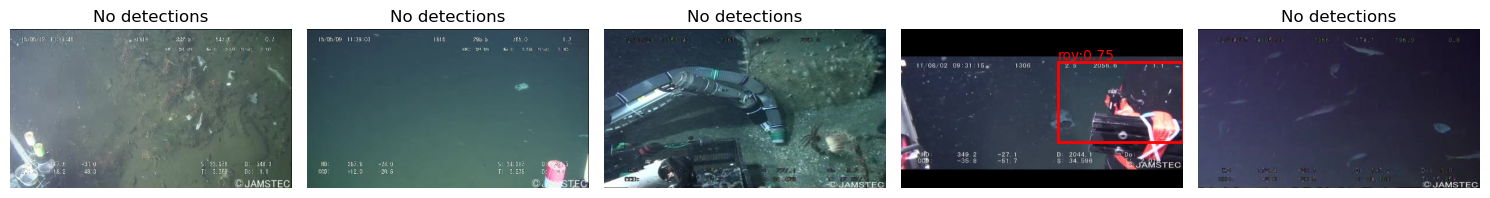

Epoch [15/100]: 100%|██████████| 387/387 [00:26<00:00, 14.62batch/s, Training loss=1.9, Validation Loss=2.03]


Showing validation sample predictions...


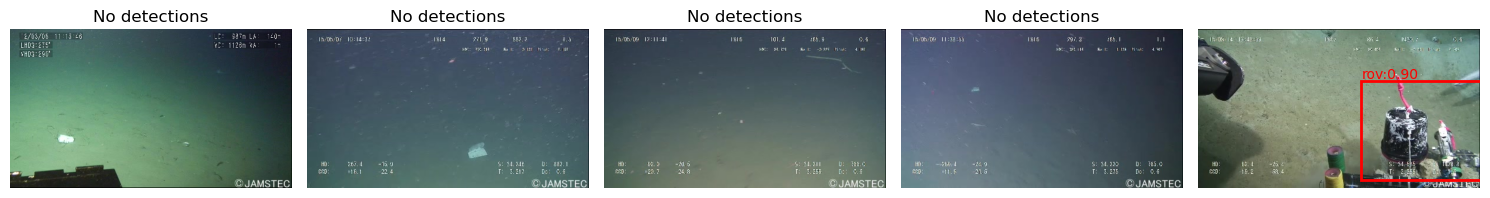

Epoch [20/100]: 100%|██████████| 387/387 [00:26<00:00, 14.85batch/s, Training loss=1.88, Validation Loss=2.02]


Showing validation sample predictions...


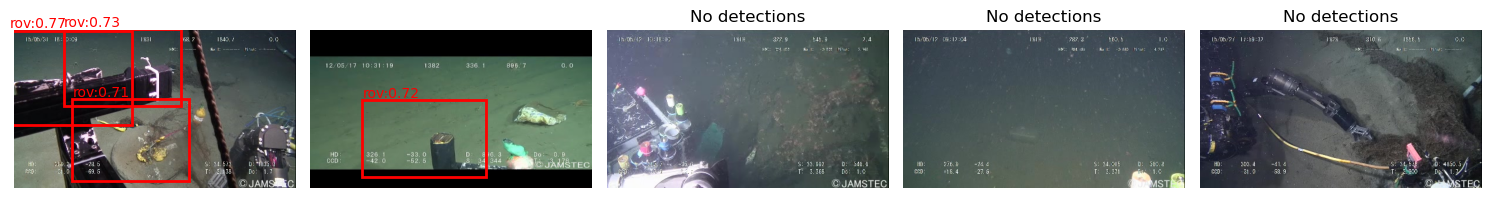

Saved ObjDetectorRPN to checkpoints\epoch_20_checkpoint.pth
Checkpoint saved: checkpoints\epoch_20_checkpoint.pth


Epoch [25/100]: 100%|██████████| 387/387 [00:24<00:00, 15.98batch/s, Training loss=1.85, Validation Loss=2.02]


Showing validation sample predictions...


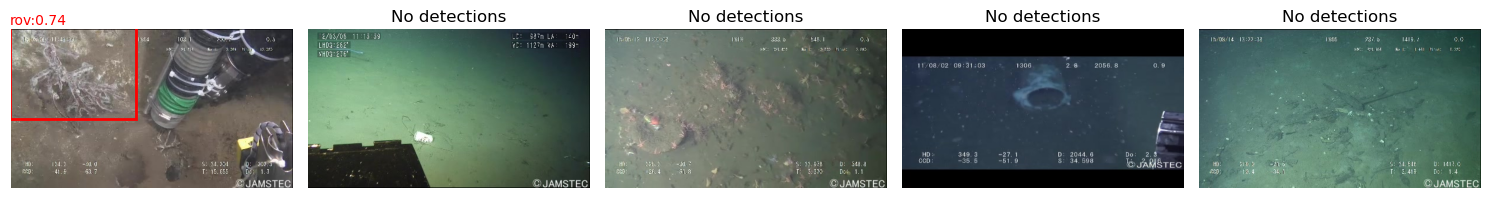

Epoch [30/100]: 100%|██████████| 387/387 [00:21<00:00, 18.08batch/s, Training loss=1.83, Validation Loss=2.02]


Showing validation sample predictions...


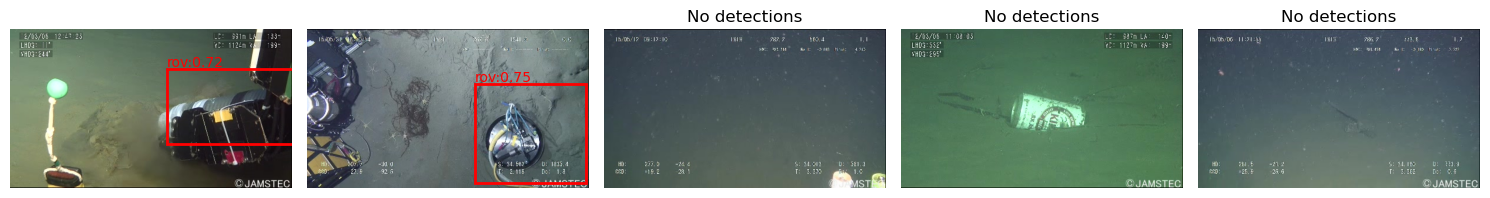

Epoch [35/100]: 100%|██████████| 387/387 [00:22<00:00, 16.97batch/s, Training loss=1.81, Validation Loss=2.01]


Showing validation sample predictions...


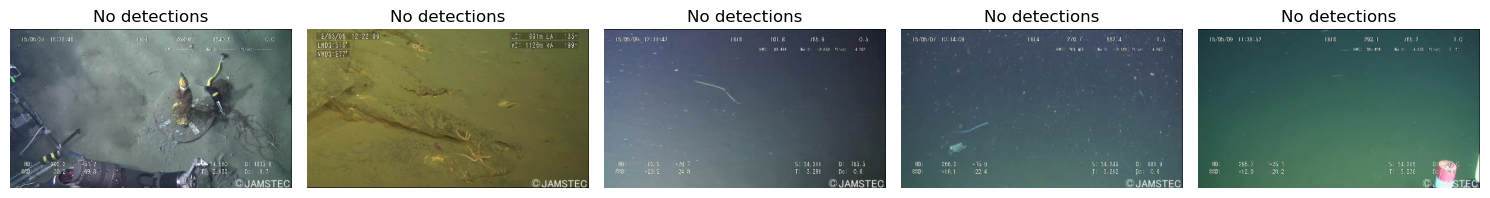

Epoch [40/100]: 100%|██████████| 387/387 [00:22<00:00, 17.52batch/s, Training loss=1.81, Validation Loss=2.02]


Showing validation sample predictions...


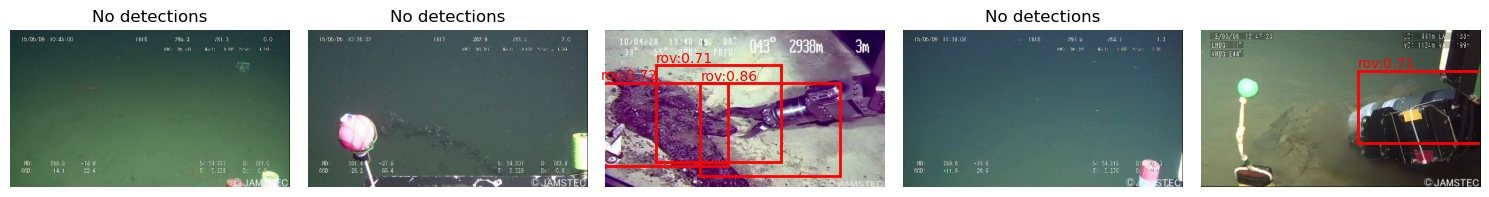

Saved ObjDetectorRPN to checkpoints\epoch_40_checkpoint.pth
Checkpoint saved: checkpoints\epoch_40_checkpoint.pth


Epoch [45/100]: 100%|██████████| 387/387 [00:21<00:00, 17.88batch/s, Training loss=1.79, Validation Loss=2.02]


Showing validation sample predictions...


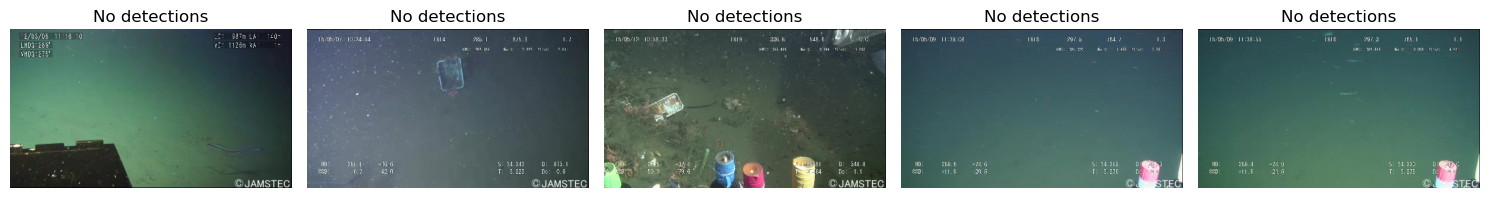

Epoch [50/100]: 100%|██████████| 387/387 [00:21<00:00, 18.02batch/s, Training loss=1.76, Validation Loss=2.01]


Showing validation sample predictions...


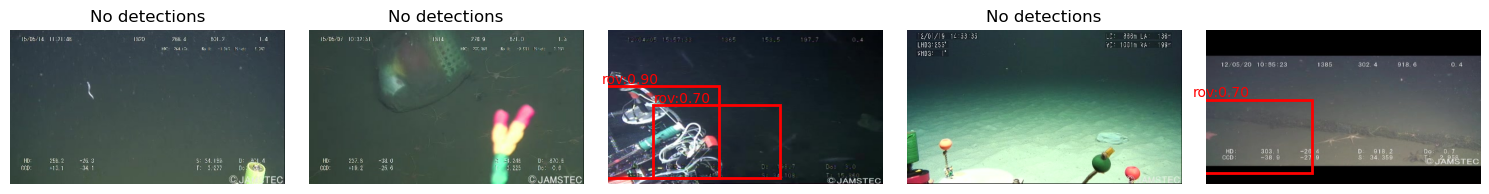

Epoch [55/100]: 100%|██████████| 387/387 [00:21<00:00, 17.87batch/s, Training loss=1.75, Validation Loss=2.02]


Showing validation sample predictions...


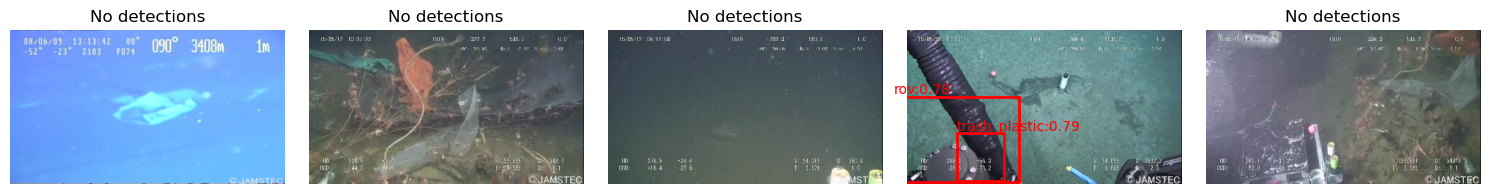

Epoch [60/100]: 100%|██████████| 387/387 [00:21<00:00, 17.92batch/s, Training loss=1.75, Validation Loss=2.02]


Showing validation sample predictions...


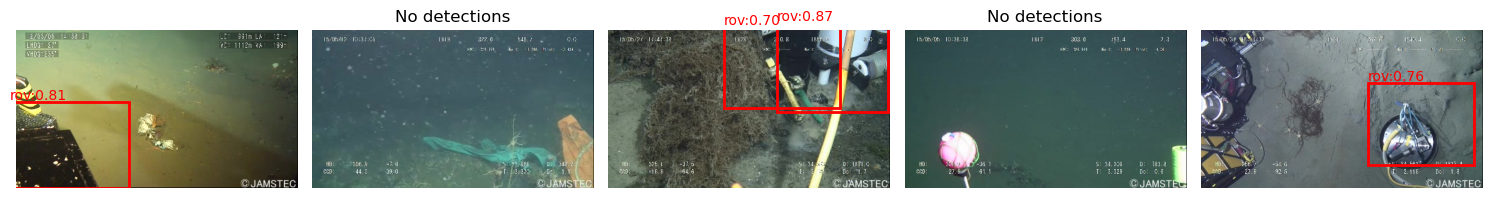

Saved ObjDetectorRPN to checkpoints\epoch_60_checkpoint.pth
Checkpoint saved: checkpoints\epoch_60_checkpoint.pth


Epoch [65/100]: 100%|██████████| 387/387 [00:21<00:00, 17.90batch/s, Training loss=1.73, Validation Loss=2.02]


Showing validation sample predictions...


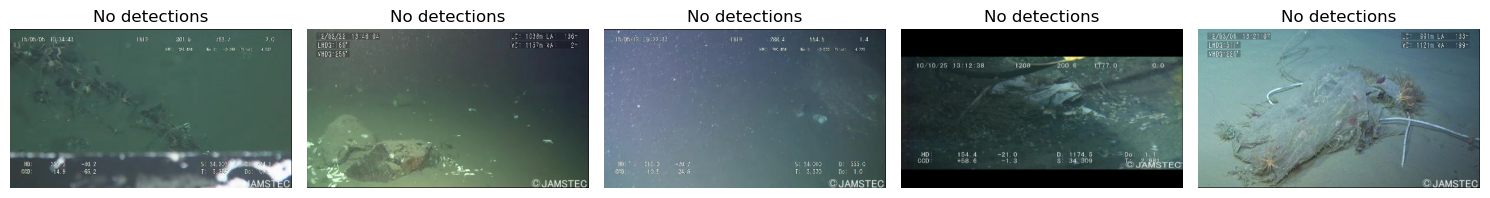

Epoch [70/100]: 100%|██████████| 387/387 [00:21<00:00, 17.88batch/s, Training loss=1.72, Validation Loss=2.02]


Showing validation sample predictions...


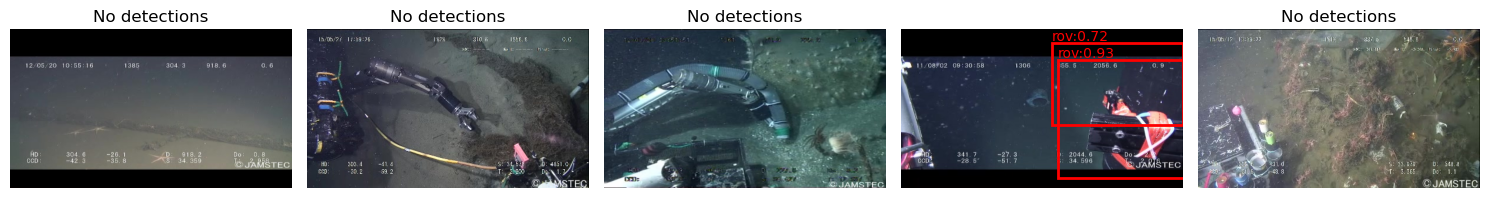

Epoch [75/100]: 100%|██████████| 387/387 [00:21<00:00, 17.88batch/s, Training loss=1.71, Validation Loss=2.02]


Showing validation sample predictions...


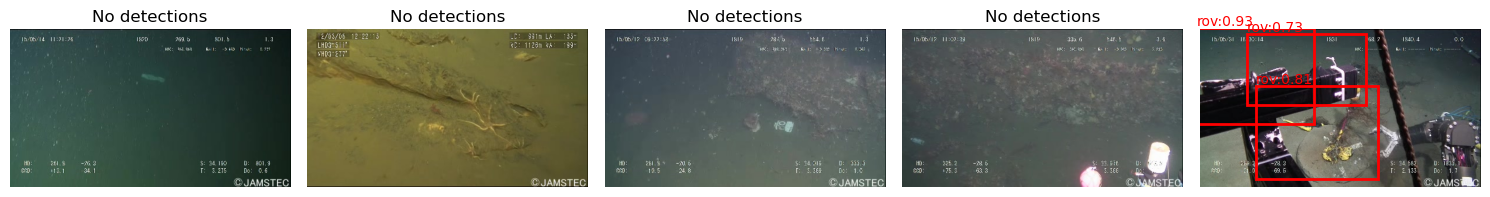

Epoch [80/100]: 100%|██████████| 387/387 [00:21<00:00, 17.95batch/s, Training loss=1.72, Validation Loss=2.03]


Showing validation sample predictions...


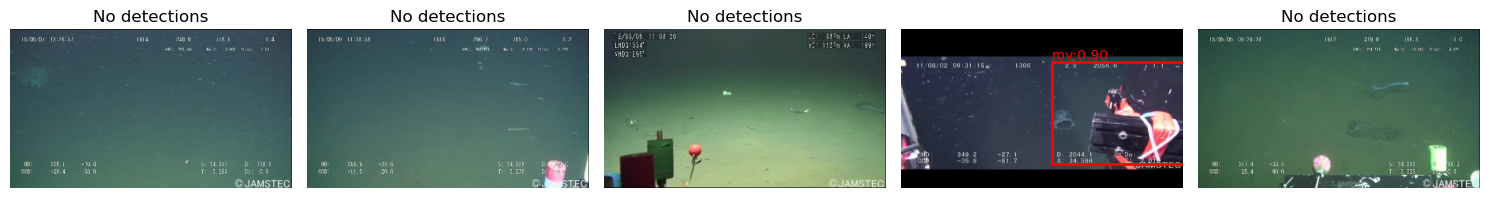

Saved ObjDetectorRPN to checkpoints\epoch_80_checkpoint.pth
Checkpoint saved: checkpoints\epoch_80_checkpoint.pth


Epoch [85/100]: 100%|██████████| 387/387 [00:21<00:00, 17.77batch/s, Training loss=1.69, Validation Loss=2.04]


Showing validation sample predictions...


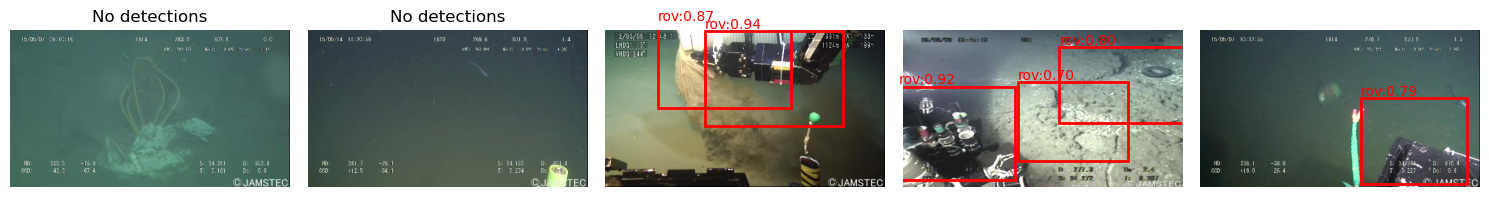

Epoch [90/100]: 100%|██████████| 387/387 [00:21<00:00, 17.78batch/s, Training loss=1.68, Validation Loss=2.03]


Showing validation sample predictions...


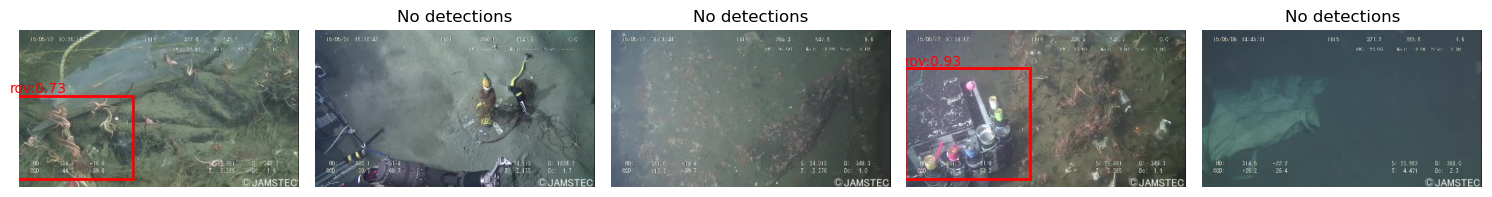

Epoch [95/100]: 100%|██████████| 387/387 [00:21<00:00, 17.95batch/s, Training loss=1.68, Validation Loss=2.04]


Showing validation sample predictions...


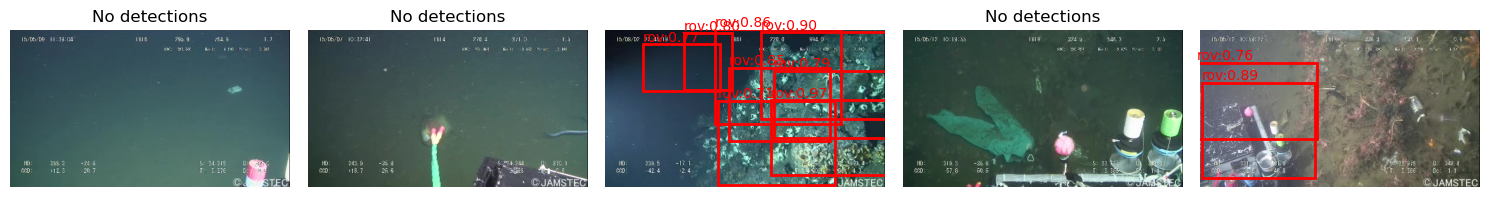

Epoch [100/100]: 100%|██████████| 387/387 [00:21<00:00, 17.96batch/s, Training loss=1.67, Validation Loss=2.04]


Showing validation sample predictions...


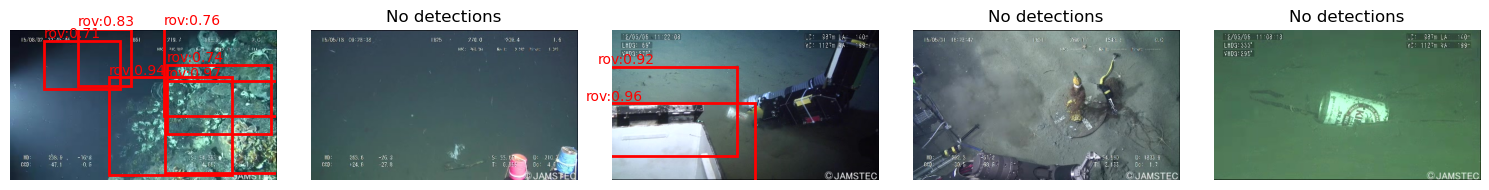

Saved ObjDetectorRPN to checkpoints\epoch_100_checkpoint.pth
Checkpoint saved: checkpoints\epoch_100_checkpoint.pth
Total Training Time : 00:38:51


In [ ]:
DATASET_PATH = os.path.join("dataset", "material_version")
IMAGE_SIZE = (480,270)
train_set = TrashCanDataset(
    image_root=os.path.join(DATASET_PATH, "train"),
    ann_path=os.path.join(DATASET_PATH, "instances_train_trashcan.json"),
    img_size=IMAGE_SIZE
)
classes= train_set.categories

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

val_set = TrashCanDataset(
    image_root=os.path.join(DATASET_PATH, "val"),
    ann_path=os.path.join(DATASET_PATH, "instances_val_trashcan.json"),
    img_size=IMAGE_SIZE
)

val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

detector = ObjDetectorRPN(classes=classes,window_step_size=32,window_size=[64,128],min_size=(64,64),image_size=IMAGE_SIZE,device=device,lr=1e-4,iou_thresh=0.5,n_clusters=64)

# detector.build_vocabulary_from_dataset(train_loader)
# detector = ObjDetectorRPN(classes=classes,device=device,iou_thresh=0.5,window_sizes=[16,64,96],window_step_size=32,lr=1e-4)
# detector = ObjDetector(classes=classes,device=device,iou_thresh=0.5,window_sizes=[64,128],window_step_size=32)
# Step 1: build BoVW vocabulary
detector.build_vocabulary_from_dataset(train_loader, max_patches=5000)
history = detector.train(train_loader,val_loader,val_set,epochs=100,vis_every=5,checkpoint_every=20)

In [ ]:
save_detector(detector,'./model.pt')

Saved ObjDetectorRPN to ./model.pt


In [ ]:
import matplotlib.pyplot as plt

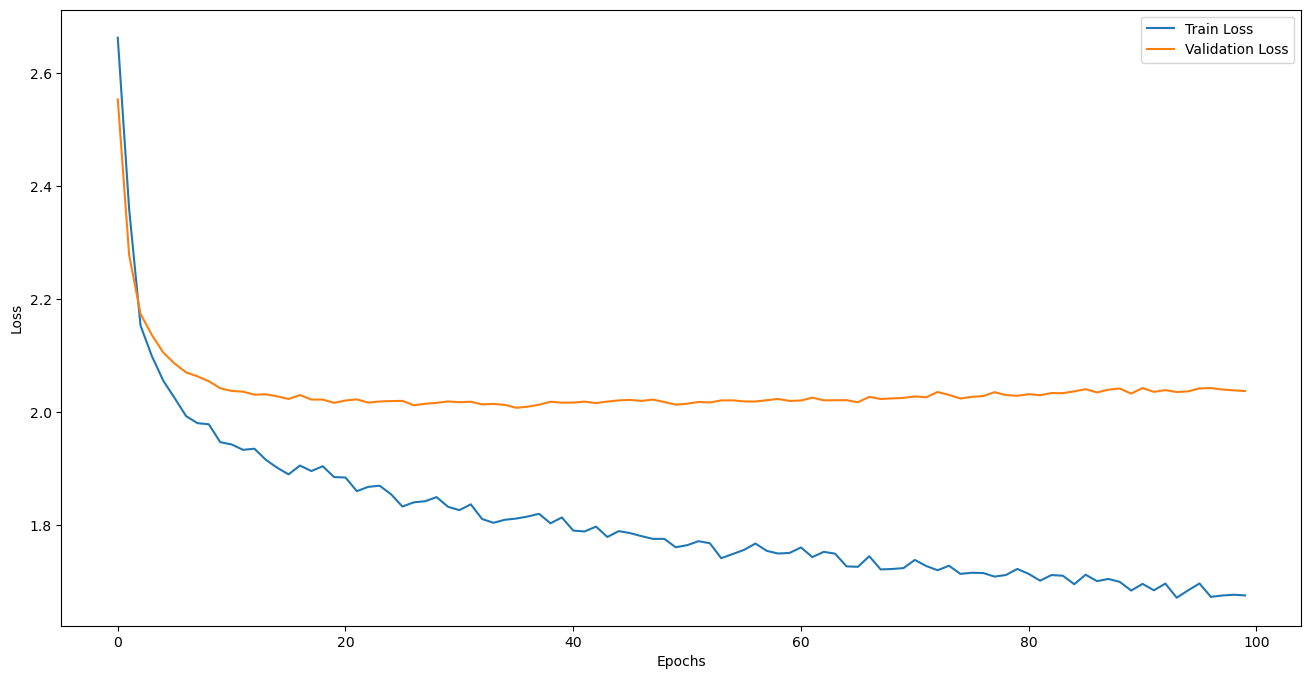

In [ ]:
train_loss = history[0]
val_loss = history[1]

plt.figure(figsize=(16,8))
plt.plot(train_loss,label='Train Loss')
plt.plot(val_loss,label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()